# CRISP-DM na Prática: Previsão de Churn em Plataforma de Streaming


## Fase 1: Entendimento do Negócio
O problema de negócio abordado neste projeto é o churn de clientes, isto é, a perda de clientes que decidem cancelar os serviços de uma empresa de telecomunicações. Em um mercado altamente competitivo, a retenção de clientes é estratégica, pois o custo de adquirir um novo cliente é significativamente maior do que o custo de manter um cliente atual.

O churn impacta diretamente indicadores-chave do negócio, como:



*   Receita recorrente

*   Lifetime Value (LTV)

*   Crescimento da base de clientes

*   Custos operacionais e de marketing

Dessa forma, compreender os fatores que levam um cliente a cancelar o serviço torna-se essencial para a sustentabilidade e crescimento da empresa.

Nesse contexto, um modelo de previsão de churn pode ser utilizado para identificar, de forma antecipada, clientes com maior probabilidade de cancelamento. A partir dessas previsões, a empresa pode adotar ações proativas de retenção, como:


*   ofertas personalizadas,

*   melhorias no atendimento,

*   ajustes em planos e serviços,

*   estratégias de relacionamento direcionadas a clientes de alto risco.

O desempenho do modelo de previsão influencia diretamente as KPIs do negócio. Um modelo com bom desempenho permite:

*  Reduzir a taxa de churn, ao identificar corretamente clientes em risco;

*  Otimizar investimentos em retenção, concentrando esforços nos clientes mais propensos a cancelar;

*  Aumentar o LTV, ao prolongar o tempo de permanência dos clientes;

*  Melhorar a eficiência operacional, evitando ações genéricas e pouco efetivas.

Por outro lado, um modelo com baixo desempenho pode gerar falsos positivos ou falsos negativos, resultando em desperdício de recursos ou perda de clientes que poderiam ter sido retidos. Assim, a qualidade do modelo preditivo é fundamental para apoiar decisões estratégicas e gerar impacto positivo nos resultados do negócio.

## Fase 2: Entendimento dos Dados

Nesta fase, exploramos o conjunto de dados para entender sua estrutura, qualidade e distribuição. Buscamos por valores faltantes, tipos de dados inconsistentes e a distribuição das variáveis.


## Dicionário de Variáveis – Telecom Churn

| Variável | Tipo | Descrição | Valores esperados |
|--------|------|-----------|-------------------|
| **Churn** | Binária | Indica se o cliente cancelou o serviço | 0 = Não cancelou<br>1 = Cancelou |
| **AccountWeeks** | Numérica (int) | Tempo de permanência do cliente na empresa (em semanas) | ≥ 0 |
| **ContractRenewal** | Binária | Indica se o cliente renovou o contrato | 0 = Não renovou<br>1 = Renovou |
| **DataPlan** | Binária | Indica se o cliente possui plano de dados | 0 = Não possui<br>1 = Possui |
| **DataUsage** | Numérica (float) | Volume de uso de dados pelo cliente | ≥ 0 |
| **CustServCalls** | Numérica (int) | Número de chamadas ao serviço de atendimento ao cliente | ≥ 0 |
| **DayMins** | Numérica (float) | Total de minutos de uso durante o dia | ≥ 0 |
| **DayCalls** | Numérica (int) | Número de chamadas realizadas durante o dia | ≥ 0 |
| **MonthlyCharge** | Numérica (float) | Valor médio da cobrança mensal | ≥ 0 |
| **OverageFee** | Numérica (float) | Taxa cobrada por uso excedente do plano | ≥ 0 |
| **RoamMins** | Numérica (float) | Quantidade de minutos utilizados em roaming | ≥ 0 |

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!curl -L -o /content/telecom-churn.zip https://www.kaggle.com/api/v1/datasets/download/barun2104/telecom-churn
!unzip /content/telecom-churn.zip -d /content/

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 46575  100 46575    0     0  85864      0 --:--:-- --:--:-- --:--:-- 85864
Archive:  /content/telecom-churn.zip
  inflating: /content/telecom_churn.csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
churn = pd.read_csv('/content/telecom_churn.csv')
churn.head()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
0,0,128,1,1,2.7,1,265.1,110,89.0,9.87,10.0
1,0,107,1,1,3.7,1,161.6,123,82.0,9.78,13.7
2,0,137,1,0,0.0,0,243.4,114,52.0,6.06,12.2
3,0,84,0,0,0.0,2,299.4,71,57.0,3.10,6.6
4,0,75,0,0,0.0,3,166.7,113,41.0,7.42,10.1


In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Churn            3333 non-null   int64  
 1   AccountWeeks     3333 non-null   int64  
 2   ContractRenewal  3333 non-null   int64  
 3   DataPlan         3333 non-null   int64  
 4   DataUsage        3333 non-null   float64
 5   CustServCalls    3333 non-null   int64  
 6   DayMins          3333 non-null   float64
 7   DayCalls         3333 non-null   int64  
 8   MonthlyCharge    3333 non-null   float64
 9   OverageFee       3333 non-null   float64
 10  RoamMins         3333 non-null   float64
dtypes: float64(5), int64(6)
memory usage: 286.6 KB


In [ ]:
churn.isna().sum()

,0
Churn,0
AccountWeeks,0
ContractRenewal,0
DataPlan,0
DataUsage,0
CustServCalls,0
DayMins,0
DayCalls,0
MonthlyCharge,0
OverageFee,0


In [ ]:
churn.duplicated().sum()

np.int64(0)

In [ ]:
churn.describe()

,Churn,AccountWeeks,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,DayCalls,MonthlyCharge,OverageFee,RoamMins
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,0.144914,101.064806,0.903090,0.276628,0.816475,1.562856,179.775098,100.435644,56.305161,10.051488,10.237294
std,0.352067,39.822106,0.295879,0.447398,1.272668,1.315491,54.467389,20.069084,16.426032,2.535712,2.791840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000
25%,0.000000,74.000000,1.000000,0.000000,0.000000,1.000000,143.700000,87.000000,45.000000,8.330000,8.500000
50%,0.000000,101.000000,1.000000,0.000000,0.000000,1.000000,179.400000,101.000000,53.500000,10.070000,10.300000
75%,0.000000,127.000000,1.000000,1.000000,1.780000,2.000000,216.400000,114.000000,66.200000,11.770000,12.100000
max,1.000000,243.000000,1.000000,1.000000,5.400000,9.000000,350.800000,165.000000,111.300000,18.190000,20.000000


In [ ]:
churn["Churn"].value_counts()

,count
Churn,
0,2850
1,483


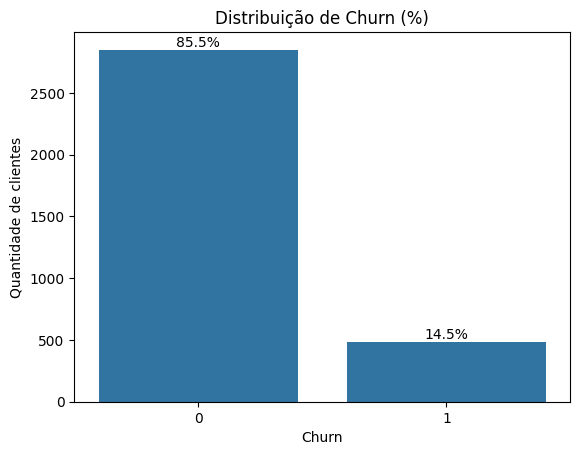

In [ ]:
# gráfico
ax = sns.countplot(x='Churn', data=churn)

# total de registros
total = len(churn)

# adicionar porcentagem em cada barra
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width() / 2., count),
                ha='center', va='bottom')

# rótulos
ax.set_xlabel('Churn')
ax.set_ylabel('Quantidade de clientes')
ax.set_title('Distribuição de Churn (%)')

plt.show()

A taxa de churn observada é de aproximadamente 14,5%, valor considerado elevado para o setor de telecomunicações, indicando a necessidade de estratégias de retenção e justificando o uso de modelos preditivos para antecipar o cancelamento de clientes.

array([[<Axes: title={'center': 'Churn'}>,
        <Axes: title={'center': 'AccountWeeks'}>,
        <Axes: title={'center': 'ContractRenewal'}>],
       [<Axes: title={'center': 'DataPlan'}>,
        <Axes: title={'center': 'DataUsage'}>,
        <Axes: title={'center': 'CustServCalls'}>],
       [<Axes: title={'center': 'DayMins'}>,
        <Axes: title={'center': 'DayCalls'}>,
        <Axes: title={'center': 'MonthlyCharge'}>],
       [<Axes: title={'center': 'OverageFee'}>,
        <Axes: title={'center': 'RoamMins'}>, <Axes: >]], dtype=object)

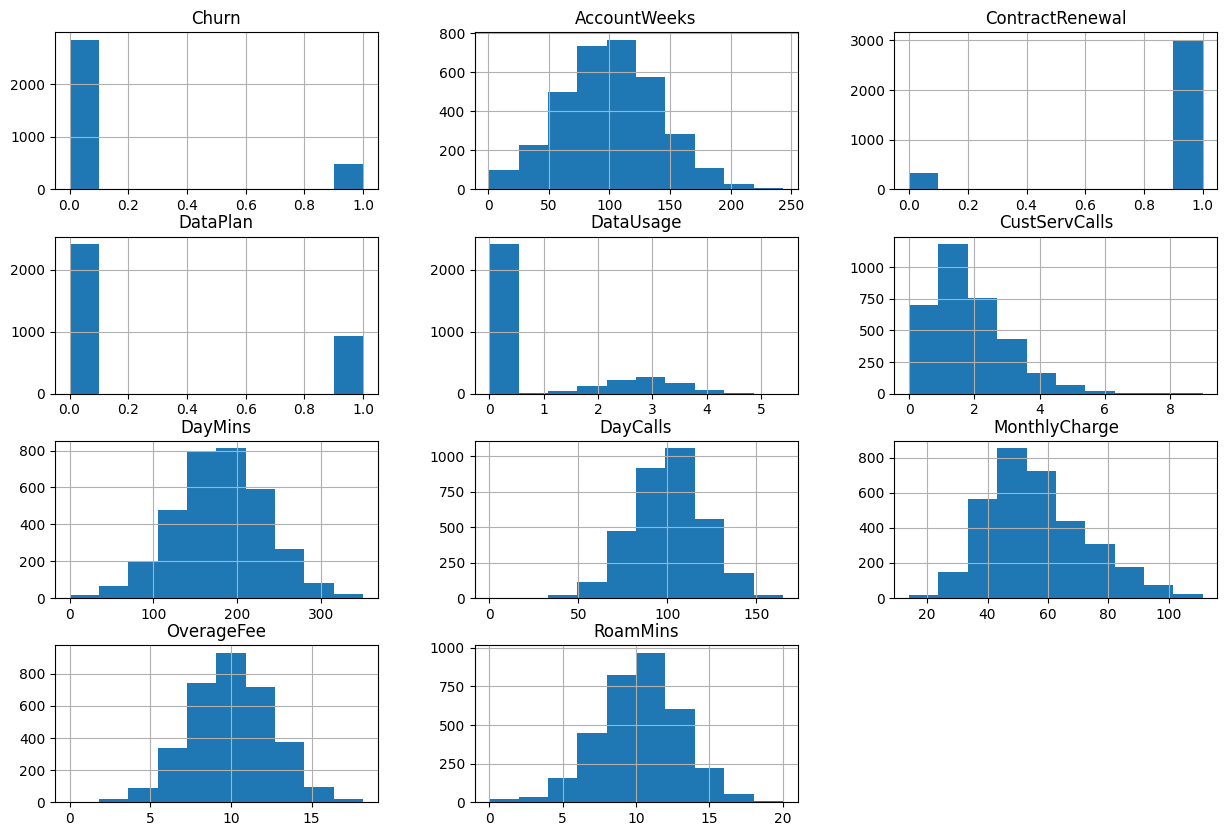

In [ ]:
churn.hist(figsize=(15,10))

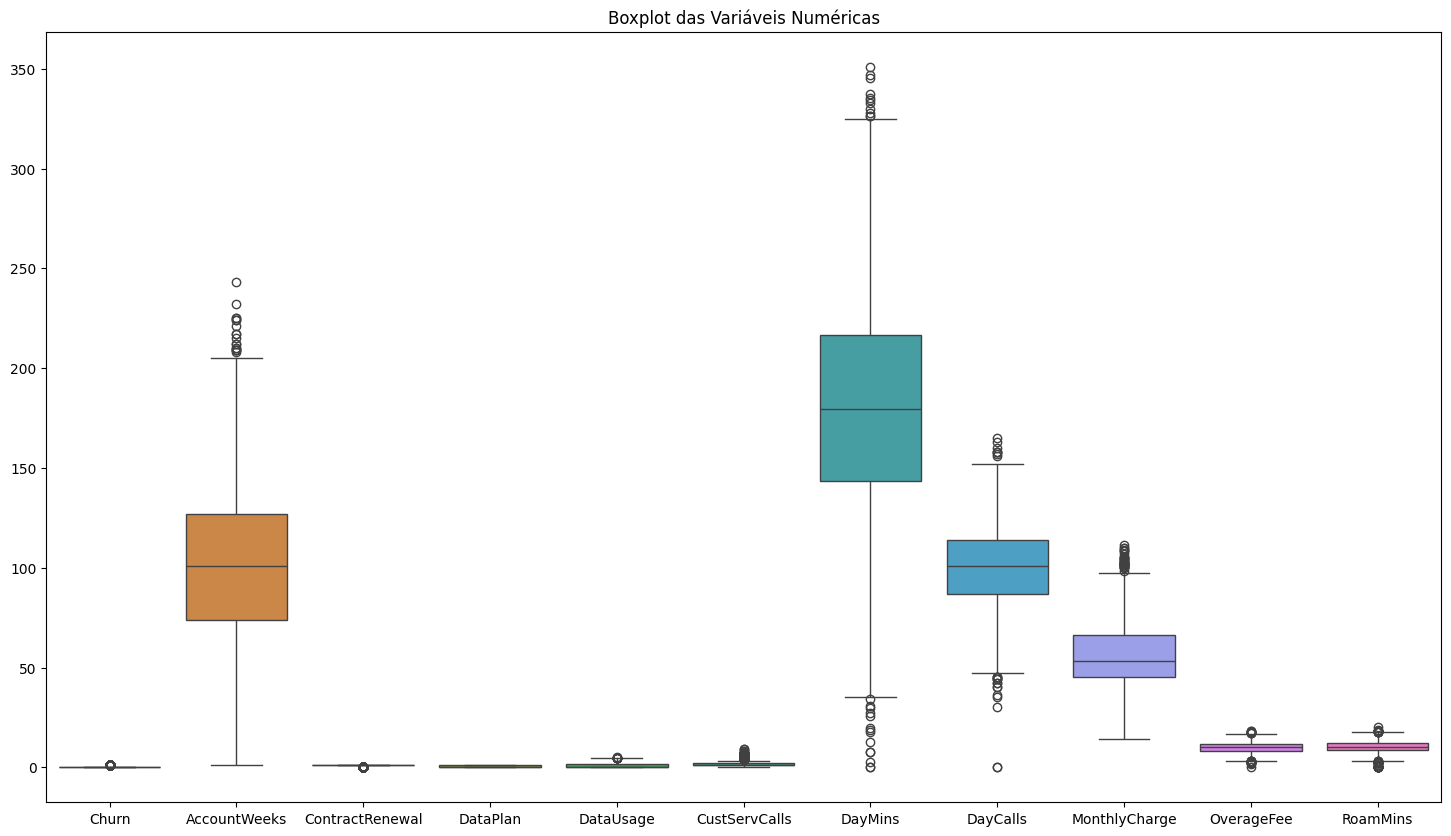

In [ ]:
plt.figure(figsize=(18, 10))
sns.boxplot(data=churn)
plt.xticks(rotation=360)
plt.title('Boxplot das Variáveis Numéricas')
plt.show()

In [ ]:
renovacao = churn.groupby('ContractRenewal')['Churn'].value_counts(normalize=True) * 100
renovacao

ContractRenewal  Churn
0                0        57.585139
                 1        42.414861
1                0        88.504983
                 1        11.495017
Name: proportion, dtype: float64

In [ ]:
renovacao_df = renovacao.unstack()
renovacao_df

Churn,0,1
ContractRenewal,,
0,57.585139,42.414861
1,88.504983,11.495017


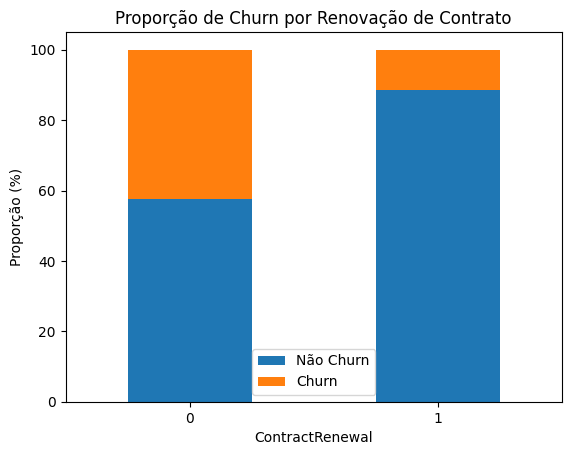

In [ ]:
renovacao_df.plot(kind='bar', stacked=True)

plt.ylabel('Proporção (%)')
plt.xlabel('ContractRenewal')
plt.title('Proporção de Churn por Renovação de Contrato')
plt.legend(['Não Churn', 'Churn'])
plt.xticks(rotation=360)
plt.show()

Observa-se uma diferença significativa na taxa de churn entre clientes que renovaram contrato e aqueles que não renovaram. Clientes sem renovação apresentam taxa de churn de aproximadamente 42%, enquanto clientes com renovação apresentam taxa inferior a 12%, indicando que a renovação contratual é um fato relevante para retenção de clientes.

In [ ]:
plano_de_dados = churn.groupby('DataPlan')['Churn'].value_counts(normalize=True) * 100
plano_de_dados

DataPlan  Churn
0         0        83.284944
          1        16.715056
1         0        91.323210
          1         8.676790
Name: proportion, dtype: float64

In [ ]:
dataplan_df = plano_de_dados.unstack()
dataplan_df

Churn,0,1
DataPlan,,
0,83.284944,16.715056
1,91.323210,8.676790


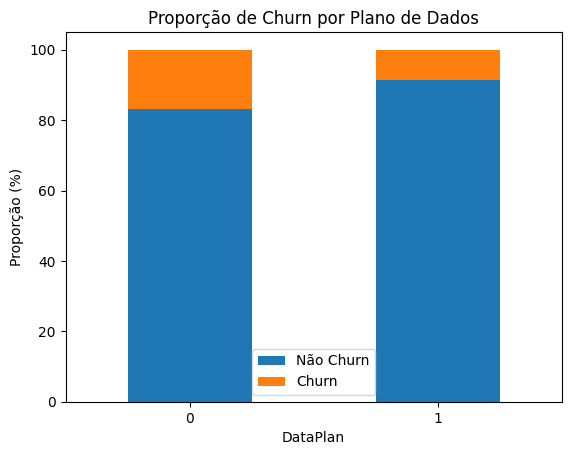

In [ ]:
dataplan_df.plot(kind='bar', stacked=True)

plt.ylabel('Proporção (%)')
plt.xlabel('DataPlan')
plt.title('Proporção de Churn por Plano de Dados')
plt.legend(['Não Churn', 'Churn'])
plt.xticks(rotation=360)
plt.show()

A análise da variável DataPlan indica que clientes sem plano de dados apresentam taxa de churn de aproximadamente 16,7%, enquanto clientes com plano de dados apresentam churn inferior a 9%. Esse resultado sugere que a adesão a serviços adicionais pode estar associada a maior fidelização dos clientes.

<Axes: xlabel='Churn', ylabel='CustServCalls'>

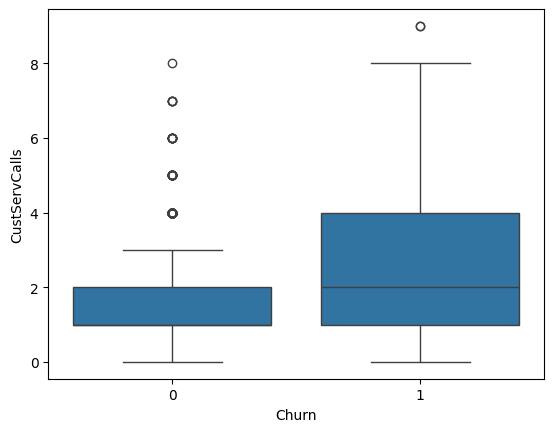

In [ ]:
sns.boxplot(x='Churn', y='CustServCalls', data=churn)

A análise da variável CustServCalls por meio de boxplot mostra que clientes que churnaram apresentam mediana e dispersão maiores no número de chamadas ao atendimento ao cliente. Esse padrão sugere que interações frequentes com o suporte estão associadas a maior probabilidade de churn, possivelmente refletindo insatisfação ou problemas recorrentes não resolvidos.

<Axes: xlabel='Churn', ylabel='MonthlyCharge'>

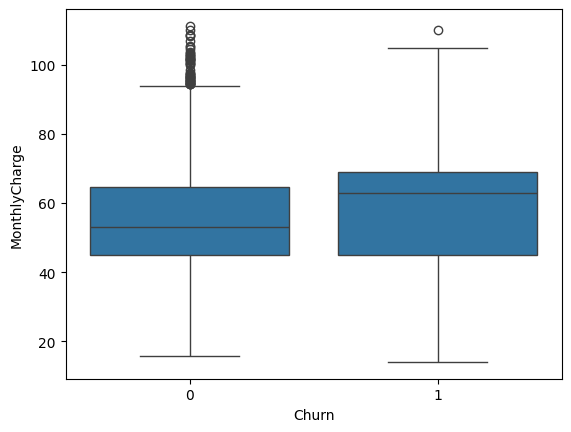

In [ ]:
sns.boxplot(x='Churn', y='MonthlyCharge', data=churn)

A análise da variável MonthlyCharge evidencia que clientes que churnaram apresentam valores medianos de cobrança mensal superiores aos clientes que permaneceram. Esse padrão indica que cobranças mais elevadas podem estar associadas a maior probabilidade de churn, sugerindo sensibilidade ao preço como um fator relevante no comportamento dos clientes.

<Axes: xlabel='Churn', ylabel='AccountWeeks'>

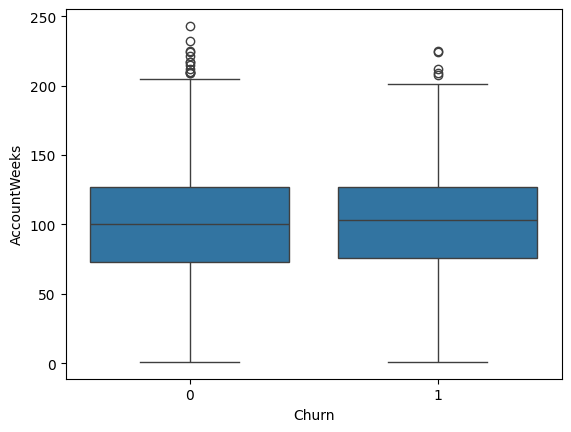

In [ ]:
sns.boxplot(x='Churn', y='AccountWeeks', data=churn)

A variável AccountWeeks não apresentou diferenças significativas entre clientes churn e não churn, com distribuições e medianas muito semelhantes entre os grupos. Esse resultado sugere que o tempo de permanência, de forma isolada, não é um fator determinante para o churn neste conjunto de dados.

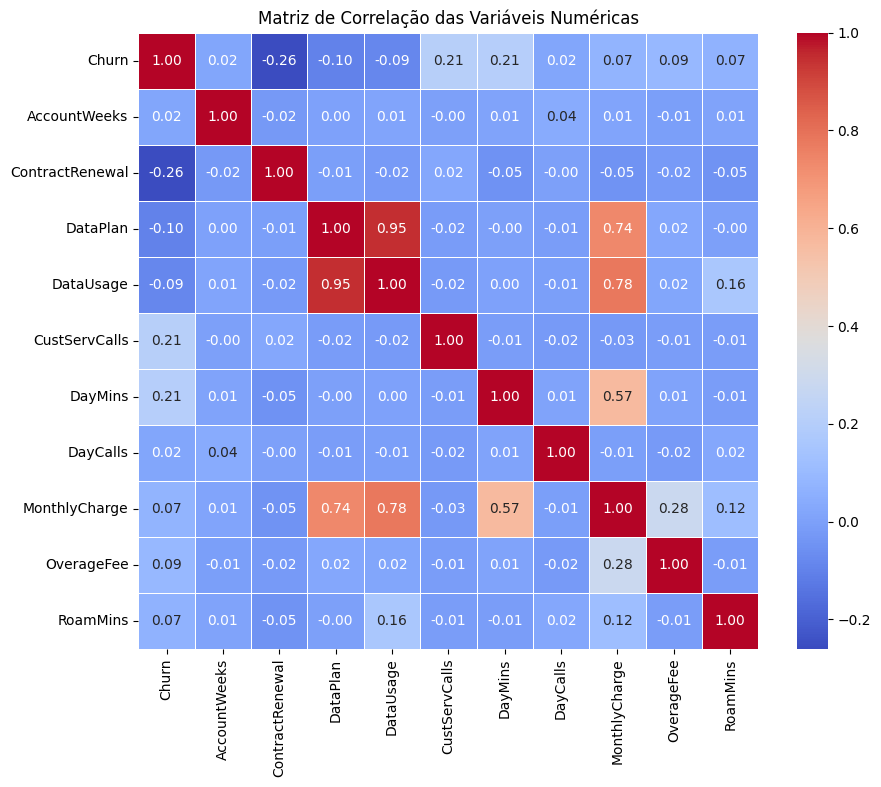

In [ ]:
corr = churn.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # mostra os números
    fmt=".2f",         # duas casas decimais
    cmap="coolwarm",
    linewidths=0.5
)

plt.title('Matriz de Correlação das Variáveis Numéricas')
plt.show()


In [ ]:
corr = churn.corr(numeric_only=True)[['Churn']].sort_values(by='Churn', ascending=False)
corr

,Churn
Churn,1.000000
CustServCalls,0.208750
DayMins,0.205151
OverageFee,0.092812
MonthlyCharge,0.072313
RoamMins,0.068239
DayCalls,0.018459
AccountWeeks,0.016541
DataUsage,-0.087195
DataPlan,-0.102148


A análise de correlação revelou que a variável mais associada ao churn foi a renovação de contrato (ContractRenewal), apresentando correlação negativa de -0,26, indicando que clientes que renovam seus contratos possuem menor propensão à evasão.

Entre as variáveis com correlação positiva, destacam-se o número de chamadas ao atendimento ao cliente (CustServCalls) e os minutos de uso diurno (DayMins), sugerindo que insatisfação com o serviço e maior intensidade de uso estão associados a maiores taxas de churn.

Variáveis como AccountWeeks e DayCalls apresentaram correlação próxima de zero, indicando baixo impacto isolado na evasão de clientes.

## Fase 3: Preparação dos Dados

# Limpeza dos Dados

Inicialmente, foi realizada uma análise exploratória para identificação de valores ausentes, registros duplicados e inconsistências estruturais. O conjunto de dados apresentou 3333 registros e 11 variáveis, não sendo identificados valores nulos ou duplicados. Todas as variáveis estavam corretamente tipadas, com atributos numéricos contínuos (float64) e discretos/binários (int64).

Dessa forma, não foi necessária a exclusão ou imputação de dados, garantindo a preservação integral da amostra original.

# Transformação de Variáveis

As variáveis categóricas binárias (Churn, ContractRenewal e DataPlan) já se encontravam codificadas no formato numérico (0 e 1), tornando-se diretamente compatíveis com algoritmos de machine learning supervisionados. Assim, não foi necessária a aplicação de técnicas adicionais de codificação, como one-hot encoding.

As variáveis numéricas contínuas foram inicialmente mantidas em sua forma original, uma vez que não apresentaram distribuições extremamente assimétricas ou problemas estruturais que justificassem transformações como normalização ou padronização nesta etapa.

# Análise de Outliers

Embora algumas variáveis, como DayMins e MonthlyCharge, apresentem valores máximos elevados, esses valores refletem comportamentos reais de uso intensivo do serviço, não caracterizando erros de medição. Considerando o contexto do problema de churn, tais valores são potencialmente informativos e, portanto, não foram removidos nem tratados como outliers.

# Engenharia de Features

Engenharia de Features

Após a análise exploratória e de correlação, optou-se por não criar novas variáveis derivadas nesta etapa, uma vez que as features originais já apresentam relação significativa com a variável alvo (Churn), especialmente:

* ContractRenewal

* CustServCalls

* DayMins

* MonthlyCharge

A criação de novas features poderá ser considerada em etapas futuras, caso o desempenho dos modelos iniciais indique necessidade de maior complexidade.

# Redução de Variáveis

Com o objetivo de simplificar o conjunto de dados e reduzir ruído, foi realizada uma análise de correlação das variáveis numéricas com a variável alvo Churn.

As variáveis DayCalls e AccountWeeks apresentaram correlação próxima de zero e não demonstraram capacidade discriminativa relevante nas análises gráficas, sendo removidas do dataset final.

In [ ]:
churn_final = churn.drop(
    columns=['DayCalls', 'AccountWeeks']
)
churn_final.head()

,Churn,ContractRenewal,DataPlan,DataUsage,CustServCalls,DayMins,MonthlyCharge,OverageFee,RoamMins
0,0,1,1,2.7,1,265.1,89.0,9.87,10.0
1,0,1,1,3.7,1,161.6,82.0,9.78,13.7
2,0,1,0,0.0,0,243.4,52.0,6.06,12.2
3,0,0,0,0.0,2,299.4,57.0,3.10,6.6
4,0,0,0,0.0,3,166.7,41.0,7.42,10.1


In [ ]:
churn_final.to_csv('churn_preparado_modelagem.csv', index=False)

In [ ]:
from google.colab import files
files.download('churn_preparado_modelagem.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Conclusão da Etapa

Ao final da Fase 3, os dados encontram-se limpos, estruturados e adequados para a modelagem, com decisões de transformação e redução baseadas em análises exploratórias e entendimento do negócio. O dataset final apresenta menor complexidade, mantendo variáveis relevantes para a previsão de churn e permitindo avançar para a próxima etapa do CRISP-DM, que consiste na construção, avaliação e comparação dos modelos preditivos.